## CSV Inspection

In [1]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import albumentations as a
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from tqdm import tqdm


GENERAL_DATASET_PATH = "/kaggle/input/datasets/sshikamaru/car-object-detection/data"
csv_file = "train_solution_bounding_boxes (1).csv"
csv_path = os.path.join(GENERAL_DATASET_PATH, csv_file)

df = pd.read_csv(csv_path)

print(df.head())
print(f"\ndata size: {df.shape}")

             image        xmin        ymin        xmax        ymax
0   vid_4_1000.jpg  281.259045  187.035071  327.727931  223.225547
1  vid_4_10000.jpg   15.163531  187.035071  120.329957  236.430180
2  vid_4_10040.jpg  239.192475  176.764801  361.968162  236.430180
3  vid_4_10020.jpg  496.483358  172.363256  630.020260  231.539575
4  vid_4_10060.jpg   16.630970  186.546010  132.558611  238.386422

data size: (559, 5)


## Checking Images Resolution


vid_4_11900.jpg with a size of (380, 676, 3)


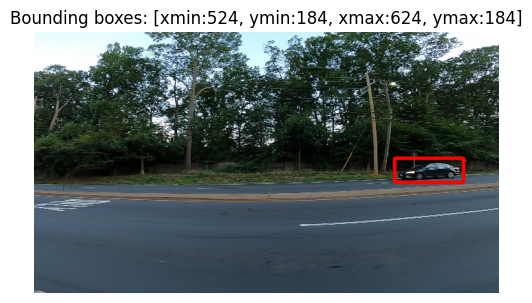


vid_4_11880.jpg with a size of (380, 676, 3)


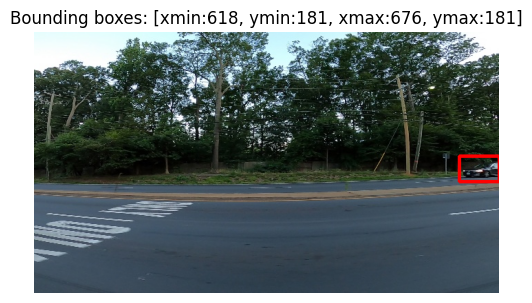


vid_4_11920.jpg with a size of (380, 676, 3)


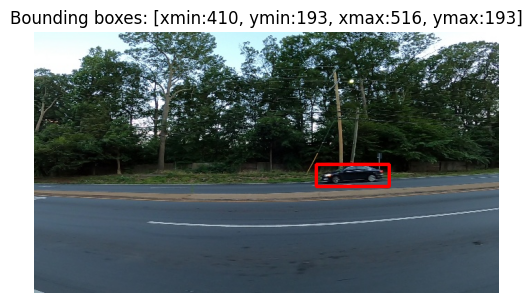


vid_4_11940.jpg with a size of (380, 676, 3)


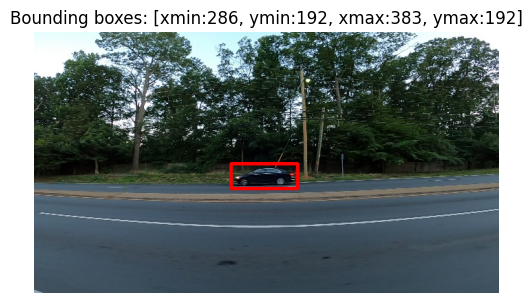


vid_4_11960.jpg with a size of (380, 676, 3)


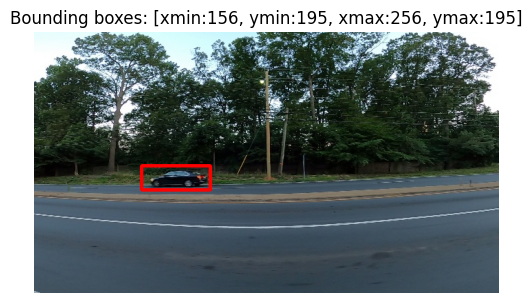

In [2]:
image_folder = "training_images"
image_path = os.path.join(GENERAL_DATASET_PATH, image_folder)

for i in range(25,30):
    file_name = df['image'].iloc[i]
    xmin = int(df['xmin'].iloc[i])
    ymin = int(df['ymin'].iloc[i])
    xmax = int(df['xmax'].iloc[i])
    ymax = int(df['ymax'].iloc[i])

    full_path = os.path.join(image_path, file_name)
    img = cv2.imread(full_path)

    if img is None:
        print(f"Error: Image {file_name} not found")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print(f"\n{file_name} with a size of {img.shape}")

    cv2.rectangle(img, (xmin, ymin), (xmax,ymax), (255, 0, 0), 3)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Bounding boxes: [xmin:{xmin}, ymin:{ymin}, xmax:{xmax}, ymax:{ymin}]")
    plt.axis('off')
    plt.show()

## Image Size Validator

In [3]:
resolution_notes = []

for index, row in df.iterrows():
    file_name = row['image']

    # ambil direktori utk tiap gambar
    full_path = os.path.join(image_path, file_name)
    img = cv2.imread(full_path)

    if img is not None:
        resolution_notes.append((img.shape[0], img.shape[1]))
    else:
        print(f"Image {file_name} not found")

img_counter = Counter(resolution_notes)

print(f"Image validated total: {len(resolution_notes)}")
print(f"\nDaftar Resolusi and Jumlah Gambar")

for resolution, jumlah in img_counter.items():
    print(f" {resolution[0]} x {resolution[1]} piksel \t\t | {jumlah} gambar\n")

if len(img_counter) == 1:
    print("All images are the same")
else:
    print("There's different images size")

Image validated total: 559

Daftar Resolusi and Jumlah Gambar
 380 x 676 piksel 		 | 559 gambar

All images are the same


## Albumentations

In [4]:
import albumentations as A

augmentation_pipeline = A.Compose([
  
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    
    # rotate_limit=15 agar kotaknya tidak terlalu miring merusak label
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.7),
    
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    
    A.HorizontalFlip(p=0.5),

    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.5),
    A.Resize(height=224, width=224)
], bbox_params = A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_24/3124814568.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_24/3124814568.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.5),


## Loading Custom Dataset

In [5]:
class SingleCarDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_name = row['image']
        full_path = os.path.join(self.image_dir, file_name)

        # taking the img 
        image = cv2.imread(full_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        
        original_bboxes = [[row['xmin'], row['ymin'], row['xmax'], row['ymax']]]
        actual_label = ['Car']

    
        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=original_bboxes,
                class_labels=actual_label
            )
            
           
            if len(transformed['bboxes']) == 0:
                # Jika hilang, gunakan Fallback (hanya di-resize paksa ke 224x224)
                fallback_transform = a.Compose([
                    a.Resize(height=224, width=224)
                ], bbox_params=a.BboxParams(format='pascal_voc', label_fields=['class_labels']))
                
                transformed = fallback_transform(
                    image=image, 
                    bboxes=original_bboxes, 
                    class_labels=actual_label
                )
                
            image = transformed['image']
            bboxes = transformed['bboxes']
        else:
            bboxes = original_bboxes

        # Normalisasi ke tensor
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        bbox = torch.tensor(bboxes[0], dtype=torch.float32)
        bbox = bbox / 224.0
    
        return image, bbox

## CBAM (Convolutional Block Attention Module)

### Channel Attention
The mechanism for finding the meaning of each pixel on the feature map works as follows, we start by summarizing each feature map through pooling, so that for each channel on the feature map we take only a single value. This is done to determine how important that channel is.

In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
    
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
    
        # Setelah ambil avg pool n max pool tiap
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction_ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction_ratio, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        out = self.sigmoid(avg_out + max_out)

        return x * out

### Spatial Attention
For example there's 64 channel

Spatial Attention works by changing lots of channel into 1, for example pixel (0,0), if we use the Max Pooling, then out of 64 channel, it will choose only 1 with the max value and this thing goes on to pixel (0,1) until the end. Vice versa for Avg Pooling. 

After this, it combines two channel (AvgPool Channel and MaxPool Channel) by Convoluting it with a 7x7 kernel cause it's optimal in the paper "Convolutional Block Attention Module". After this, CBAM basically creates an important 1 channel heatmap (combination of max channel and avg channel) then readjust the weight by doing a dot-product with the 64 channel before.

In [7]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()

        padding = kernel_size // 2
        # buat fungsi untuk konvolusi nanti antara channel max and avg
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # ambil 2 channel yg dimana setiap pikselnya bernilai max and avg
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg_out, max_out], dim=1)

        out = self.sigmoid(self.conv(x_cat))

        return x * out

In [8]:
class CBAM(nn.Module):
    def __init__(self, in_channels):
        super(CBAM, self).__init__()
        self.CA = ChannelAttention(in_channels)
        self.SA = SpatialAttention()

    def forward(self, x):
        x = self.CA(x)
        x = self.SA(x)

        return x

## Residual Bottleneck + Skip Connection

In [9]:
class ResidualBottleneck(nn.Module):

    expansion =4
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        expanded_channels = out_channels * self.expansion
        self.conv3 = nn.Conv2d(out_channels, expanded_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(expanded_channels)

        self.cbam = CBAM(expanded_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != expanded_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, expanded_channels, kernel_size=1, 
                          stride=stride, bias=False),
                nn.BatchNorm2d(expanded_channels)
            )


    def forward(self, x):
        # simpan data asli di awal
        first_identity = self.shortcut(x)

        # (1x1 -> ReLU -> 3x3 -> ReLU -> 1x1)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        # Alirkan ke Mata Batin untuk menghapus noise aspal/awan
        out = self.cbam(out)

        # SKIP CONNNECTIONS (dengan cara tambah tensor asli ke hasil akhir)
        out += first_identity

        out = self.relu(out)
        return out

## CarLocatorFPN

In [10]:
class CarLocatorFPN(nn.Module):
    def __init__(self, block, num_blocks):
        super(CarLocatorFPN, self).__init__()
        self.in_channels = 64

        # STEM
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        # Backbone
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1) 
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2) 
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)  
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # FPN NECK
        self.fpn_c5_p5 = nn.Conv2d(2048, 256, kernel_size=1)
        self.fpn_c4_p4 = nn.Conv2d(1024, 256, kernel_size=1)
        self.fpn_c3_p3 = nn.Conv2d(512, 256, kernel_size=1)

        self.fpn_p4_smooth = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.fpn_p3_smooth = nn.Conv2d(256, 256, kernel_size=3, padding=1)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion # Update channel
        return nn.Sequential(*layers)

    def forward(self, x):

        # Bottom Up (Phase 1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        c2 = self.layer1(x)   # 56x56 
        c3 = self.layer2(c2)  # 28x28 
        c4 = self.layer3(c3)  # 14x14
        c5 = self.layer4(c4)  # 7x7  

       # Top Down FPN
        p5 = self.fpn_c5_p5(c5)
        p4_lateral = self.fpn_c4_p4(c4) 
        p5_upsampled = F.interpolate(p5, size=p4_lateral.shape[2:], mode='nearest')
        
        # Combine p5 and p4 knowledge
        p4 = p4_lateral + p5_upsampled 
        p4 = self.fpn_p4_smooth(p4) # Rapihkan


        p3_lateral = self.fpn_c3_p3(c3)
        p4_upsampled = F.interpolate(p4, size=p3_lateral.shape[2:], mode='nearest')
        # Combine p3 and p4 knowledge
        p3 = p3_lateral + p4_upsampled
        p3 = self.fpn_p3_smooth(p3) 

  
        return p3, p4, p5

## Custom CIoU Loss

In [11]:
from torchvision.ops import complete_box_iou_loss
import torch

def calculate_yolo_loss(pred_boxes, target_boxes):
    """
    pred_boxes: Keluaran dari GlobalRegressionHead -> format [cx, cy, w, h]
    target_boxes: Kunci jawaban dari CSV (Ground Truth) -> format [xmin, ymin, xmax, ymax]
    """
    
    cx = pred_boxes[:, 0]
    cy = pred_boxes[:, 1]
    w  = pred_boxes[:, 2]
    h  = pred_boxes[:, 3]
    
    pred_xmin = cx - (w / 2)
    pred_ymin = cy - (h / 2)
    pred_xmax = cx + (w / 2)
    pred_ymax = cy + (h / 2)
    
    pred_boxes_xyxy = torch.stack([pred_xmin, pred_ymin, pred_xmax, pred_ymax], dim=1)
    
    loss = complete_box_iou_loss(boxes1=pred_boxes_xyxy, boxes2=target_boxes, reduction='mean')
    
    return loss

## Regression Head with SiLU Activation

In [12]:
class GlobalRegressionHead(nn.Module):
    def __init__(self, in_channels=256, num_coordinates=4):
        super(GlobalRegressionHead, self).__init__()
        
        self.conv = nn.Conv2d(in_channels, 256, kernel_size=3, padding=1, bias=False)
        self.bn2d = nn.BatchNorm2d(256)
        self.silu = nn.SiLU()
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        # 256 * 3 = 768 channel input
        self.bn1d = nn.BatchNorm1d(768)
        self.fc = nn.Linear(768, num_coordinates)
        self.sigmoid = nn.Sigmoid()

    def forward(self, p3, p4, p5):
        # Extract feature for each resolution
        x3 = self.silu(self.bn2d(self.conv(p3)))
        x4 = self.silu(self.bn2d(self.conv(p4)))
        x5 = self.silu(self.bn2d(self.conv(p5)))
        
        x3 = self.pool(x3).view(x3.size(0), -1) 
        x4 = self.pool(x4).view(x4.size(0), -1) 
        x5 = self.pool(x5).view(x5.size(0), -1) 
        
        merged_features = torch.cat([x3, x4, x5], dim=1)
        merged_features = self.bn1d(merged_features)
        
        out = self.fc(merged_features)
    
        return self.sigmoid(out)

class FullCarDetector(nn.Module):
    def __init__(self, block, num_blocks):
        super(FullCarDetector, self).__init__()
        self.backbone = CarLocatorFPN(block, num_blocks)
        self.head = GlobalRegressionHead(in_channels=256)

    def forward(self, images):
        p3, p4, p5 = self.backbone(images)
        final_prediction = self.head(p3, p4, p5) 
        
        return final_prediction

## Data Loader & Optimizer

In [13]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
val_transform = A.Compose([
    A.Resize(height=224, width=224)
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))


train_dataset = SingleCarDataset(train_df, image_dir=image_path, transform=augmentation_pipeline)
val_dataset = SingleCarDataset(val_df, image_dir=image_path, transform=val_transform)

# Dataloader with num_workers 2
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training initialized on device: {device}")

# Initialize the Full Car Detector with ResNet-50 style blocks [3, 4, 6, 3]
model = FullCarDetector(ResidualBottleneck, [3, 4, 6, 3]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

Training initialized on device: cuda


## Training & Validation

In [14]:
num_epochs = 300

for epoch in range(num_epochs):
    model.train() 
    train_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]")
    
    for images, targets in loop:
        # Move tensors to the designated device (GPU/CPU)
        images = images.to(device)
        targets = targets.to(device) 
        
        optimizer.zero_grad()     
        # Forward pass [cx, cy, w, h]
        predictions = model(images) 
        
        # CIoU loss
        loss = calculate_yolo_loss(predictions, targets) 
        
        loss.backward() 
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step() 
        
        
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    
   # Validation
    model.eval() # Freeze BatchNorm and Dropout for evaluation
    val_loss = 0.0
    
    # Disable autograd engine to save memory and compute during validation
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            
            predictions = model(images)
            loss = calculate_yolo_loss(predictions, targets)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # ---------------------------------------
    # END OF EPOCH REPORTING
    # ---------------------------------------
    print(f"Epoch {epoch+1} Report: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f}\n")

print("Training Complete!")

Epoch 1/300 [TRAIN]: 100%|██████████| 14/14 [00:11<00:00,  1.25it/s, loss=1.11]


Epoch 1 Report: Train Loss = 1.1461 | Val Loss = 1.1174



Epoch 2/300 [TRAIN]: 100%|██████████| 14/14 [00:07<00:00,  1.80it/s, loss=1.07]


Epoch 2 Report: Train Loss = 1.0983 | Val Loss = 1.1487



Epoch 3/300 [TRAIN]: 100%|██████████| 14/14 [00:07<00:00,  1.81it/s, loss=1.1]


...

Epoch 298 Report: Train Loss = 0.7151 | Val Loss = 1.1874



Epoch 299/300 [TRAIN]: 100%|██████████| 14/14 [00:09<00:00,  1.53it/s, loss=0.781]


Epoch 299 Report: Train Loss = 0.7345 | Val Loss = 1.1585



Epoch 300/300 [TRAIN]: 100%|██████████| 14/14 [00:09<00:00,  1.53it/s, loss=0.669]


Epoch 300 Report: Train Loss = 0.7462 | Val Loss = 1.1540

Training Complete!
